<a href="https://colab.research.google.com/github/carlos-moreiragit/tc04/blob/main/Tech_Challenge_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf


In [3]:
# Monta o Google Drive para salvar o modelo treinado

from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [19]:
# Cria um df com os dados das ações do Google em 2024/2025

ticker = 'GOOGL'
start_date = '2024-01-01'
end_date = '2025-12-31'
df = yf.download(ticker,start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


# Verificação e Pré-Processamento dos Dados

In [20]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2024-01-02,137.133850,138.404250,135.456521,137.511005,23711200
2024-01-03,137.878220,138.582902,136.052022,136.220745,24212100
2024-01-04,135.367203,138.116435,135.327509,137.381978,27137700
2024-01-05,134.712158,136.131443,134.136506,135.724513,22513900
2024-01-08,137.798828,137.967551,135.238174,135.267948,21404000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   501 non-null    float64
 1   (High, GOOGL)    501 non-null    float64
 2   (Low, GOOGL)     501 non-null    float64
 3   (Open, GOOGL)    501 non-null    float64
 4   (Volume, GOOGL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


In [22]:
# Verifica valores nulos

print(df.isnull().sum())

Price   Ticker
Close   GOOGL     0
High    GOOGL     0
Low     GOOGL     0
Open    GOOGL     0
Volume  GOOGL     0
dtype: int64


# Visualização dos dados e a sua distribuição

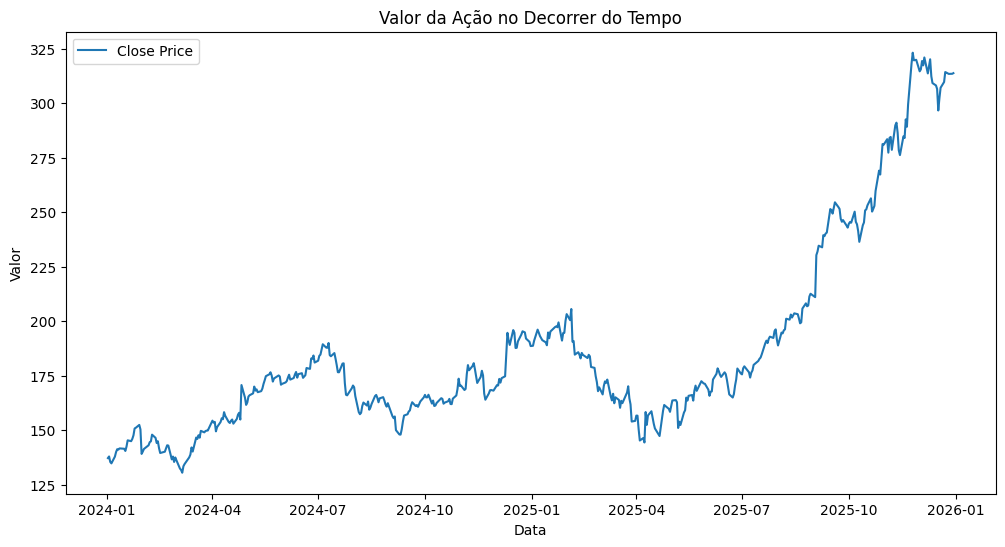

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price')
plt.title("Valor da Ação no Decorrer do Tempo")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.show()

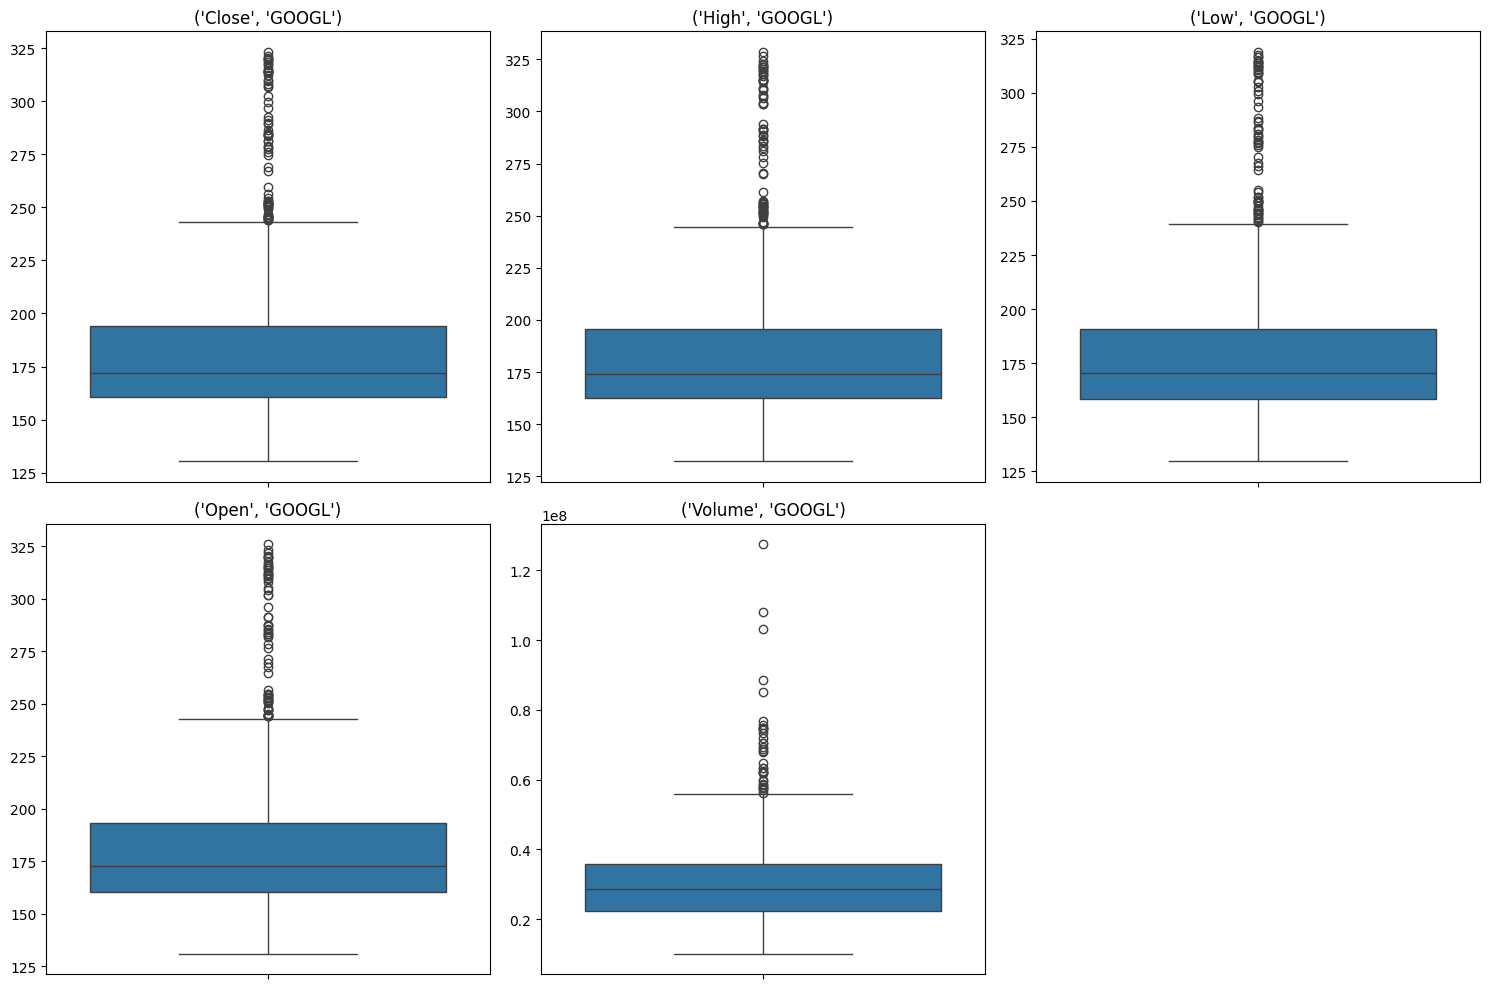

In [24]:
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

# Verificando ADF (Augmented Dickey-Fuller)

In [25]:
from statsmodels.tsa.stattools import adfuller

# Extract the 'Close' column as a series
close_series = df['Close']

# Run ADF test
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("A série é estacionária")
    else:
        print("A série não é estacionária")

check_stationarity(close_series)

ADF Statistic: 1.0296844854694809
p-value: 0.9945694867396646
The series is not stationary.


# Dimensionamento dos Dados (scaling)

In [26]:
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [27]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

# Extrai a feature
close_values = df['Close'].values

# Cria o dataset com a janela de look_back
X, Y = create_dataset(close_values, look_back = 30)

# Divide o dataset entre traino e teste
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.2, shuffle = False)

# Reshaping dos dados para o modelo LSTM

In [28]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

# Modelo Long Short-Term Memory (LSTM)

In [29]:
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=100, batch_size=32)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0388
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0035
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3135e-04
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5067e-04
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7549e-04
Epoch 14/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.2571e-04
Epoch 15/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0

# Comparando Previsto X Resultados

In [30]:
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


# Verificando o Root Mean Squared Error (RMSE)

In [31]:
rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 6.634118365761512


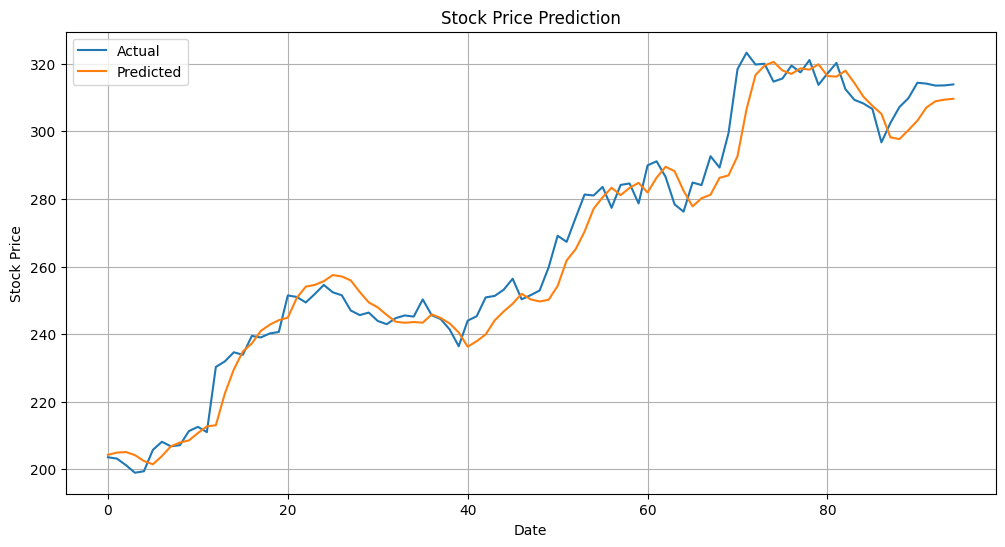

In [32]:
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

# Salvando e carregando o modelo salvo no Google Drive

In [ ]:
import pickle

# Define the file path in Google Drive
model_path = '/content/gdrive/MyDrive/tc04.pkl'

# Save the model to the specified path
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model successfully saved to {model_path}")


Model successfully saved to /content/gdrive/MyDrive/tc04.pkl


In [ ]:
# Carrega o modelo saldo no Google Drive

import pickle

# Define the exact same file path
model_path = '/content/gdrive/MyDrive/tc04.pkl'

# Load the model from the specified path
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

print(f"Model successfully loaded from {model_path}")

# You can now use the loaded_model for predictions
# predictions = loaded_model.predict(X_test)


Model successfully loaded from /content/gdrive/MyDrive/tc04.pkl
